In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("All libraries loaded successfully!")

All libraries loaded successfully!


In [2]:
# Load the dataset
df = pd.read_csv('../data/medicare_data_2022.csv', nrows=100000)

print("Data loaded successfully!")
print(f"Shape: {df.shape}")
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

Data loaded successfully!
Shape: (100000, 81)
Rows: 100,000
Columns: 81


In [3]:
# Select only the important columns we need
columns_needed = [
    'Rndrng_NPI',
    'Rndrng_Prvdr_Last_Org_Name',
    'Rndrng_Prvdr_First_Name',
    'Rndrng_Prvdr_Type',
    'Rndrng_Prvdr_State_Abrvtn',
    'Rndrng_Prvdr_City',
    'Tot_Benes',
    'Tot_Srvcs',
    'Tot_Sbmtd_Chrg',
    'Tot_Mdcr_Alowd_Amt',
    'Tot_Mdcr_Pymt_Amt',
    'Bene_Avg_Age',
    'Bene_Feml_Cnt',
    'Bene_Male_Cnt',
    'Bene_Avg_Risk_Scre'
]

# Create a new smaller dataframe
df_clean = df[columns_needed].copy()

# Rename columns
df_clean.columns = [
    'NPI', 'Last_Name', 'First_Name', 'Provider_Type',
    'State', 'City', 'Total_Beneficiaries', 'Total_Services',
    'Total_Submitted_Charges', 'Total_Medicare_Allowed',
    'Total_Medicare_Payment', 'Avg_Age', 'Female_Count',
    'Male_Count', 'Avg_Risk_Score'
]

# Clean data
df_clean['First_Name'] = df_clean['First_Name'].fillna('Organization')
df_clean['Female_Count'] = df_clean['Female_Count'].fillna(0)
df_clean['Male_Count'] = df_clean['Male_Count'].fillna(0)
df_clean = df_clean.dropna(subset=['Total_Medicare_Payment', 'Total_Services'])

print("✅ Data cleaned successfully!")
print(f"Final shape: {df_clean.shape}")

✅ Data cleaned successfully!
Final shape: (100000, 15)


✅ Clean data saved!


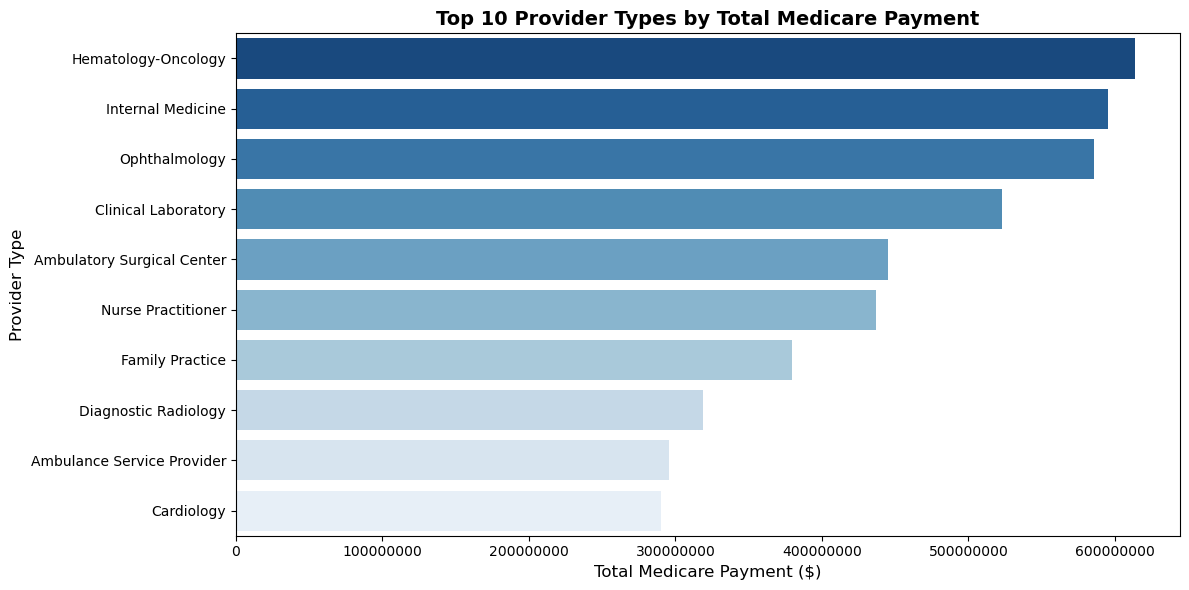

✅ Chart 1 saved!


In [4]:
# Save cleaned data
df_clean.to_csv('../output/medicare_clean.csv', index=False)
print("✅ Clean data saved!")

# Chart 1: Top 10 Provider Types by Medicare Payment
plt.figure(figsize=(12, 6))
top_providers = df_clean.groupby('Provider_Type')['Total_Medicare_Payment']\
                .sum().sort_values(ascending=False).head(10)
sns.barplot(x=top_providers.values, y=top_providers.index, palette='Blues_r')
plt.title('Top 10 Provider Types by Total Medicare Payment', fontsize=14, fontweight='bold')
plt.xlabel('Total Medicare Payment ($)', fontsize=12)
plt.ylabel('Provider Type', fontsize=12)
plt.ticklabel_format(style='plain', axis='x')
plt.tight_layout()
plt.savefig('../output/top_providers.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 1 saved!")

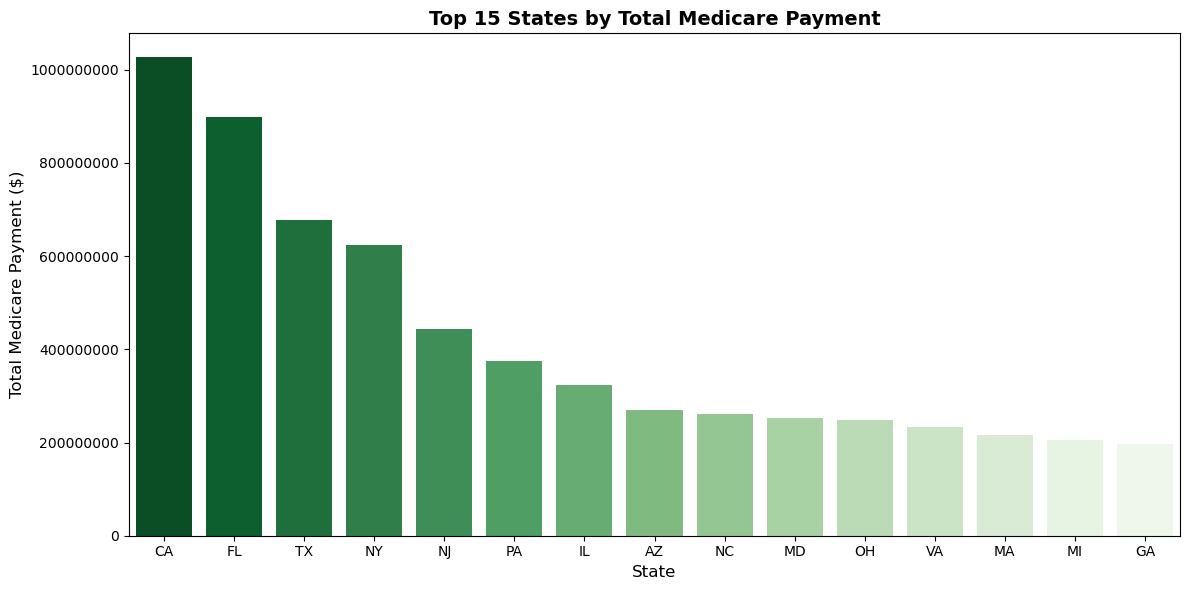

✅ Chart 2 saved!


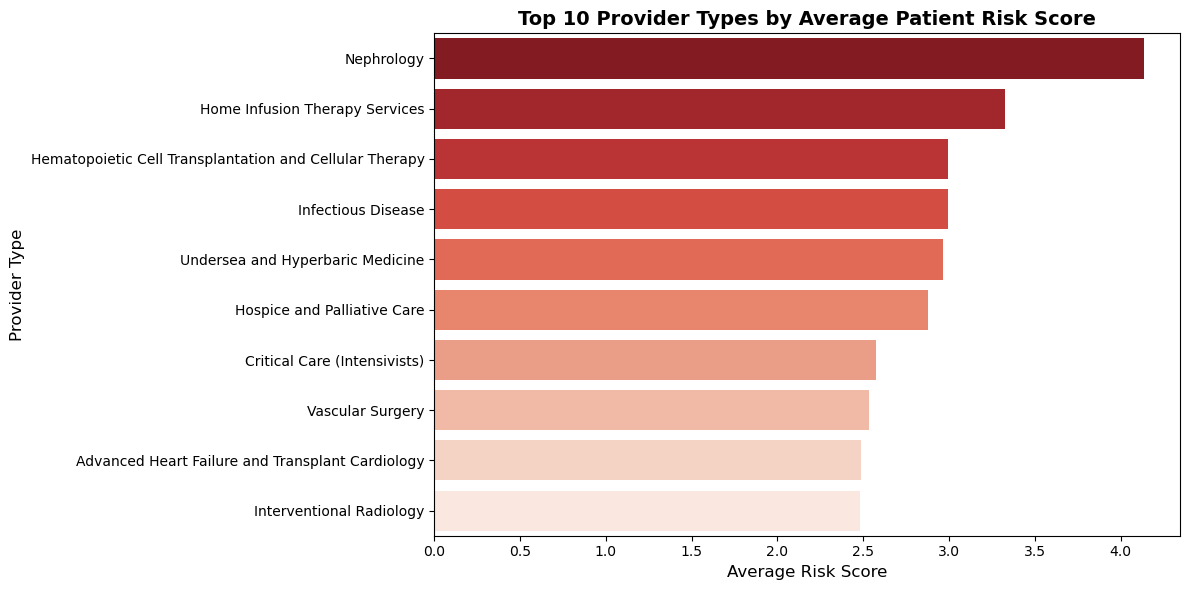

✅ Chart 3 saved!


In [5]:
# Chart 2: Top 15 States by Medicare Payment
plt.figure(figsize=(12, 6))
top_states = df_clean.groupby('State')['Total_Medicare_Payment']\
             .sum().sort_values(ascending=False).head(15)
sns.barplot(x=top_states.index, y=top_states.values, palette='Greens_r')
plt.title('Top 15 States by Total Medicare Payment', fontsize=14, fontweight='bold')
plt.xlabel('State', fontsize=12)
plt.ylabel('Total Medicare Payment ($)', fontsize=12)
plt.ticklabel_format(style='plain', axis='y')
plt.tight_layout()
plt.savefig('../output/top_states.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 2 saved!")

# Chart 3: Average Risk Score by Provider Type
plt.figure(figsize=(12, 6))
avg_risk = df_clean.groupby('Provider_Type')['Avg_Risk_Score']\
           .mean().sort_values(ascending=False).head(10)
sns.barplot(x=avg_risk.values, y=avg_risk.index, palette='Reds_r')
plt.title('Top 10 Provider Types by Average Patient Risk Score', fontsize=14, fontweight='bold')
plt.xlabel('Average Risk Score', fontsize=12)
plt.ylabel('Provider Type', fontsize=12)
plt.tight_layout()
plt.savefig('../output/avg_risk_score.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 3 saved!")

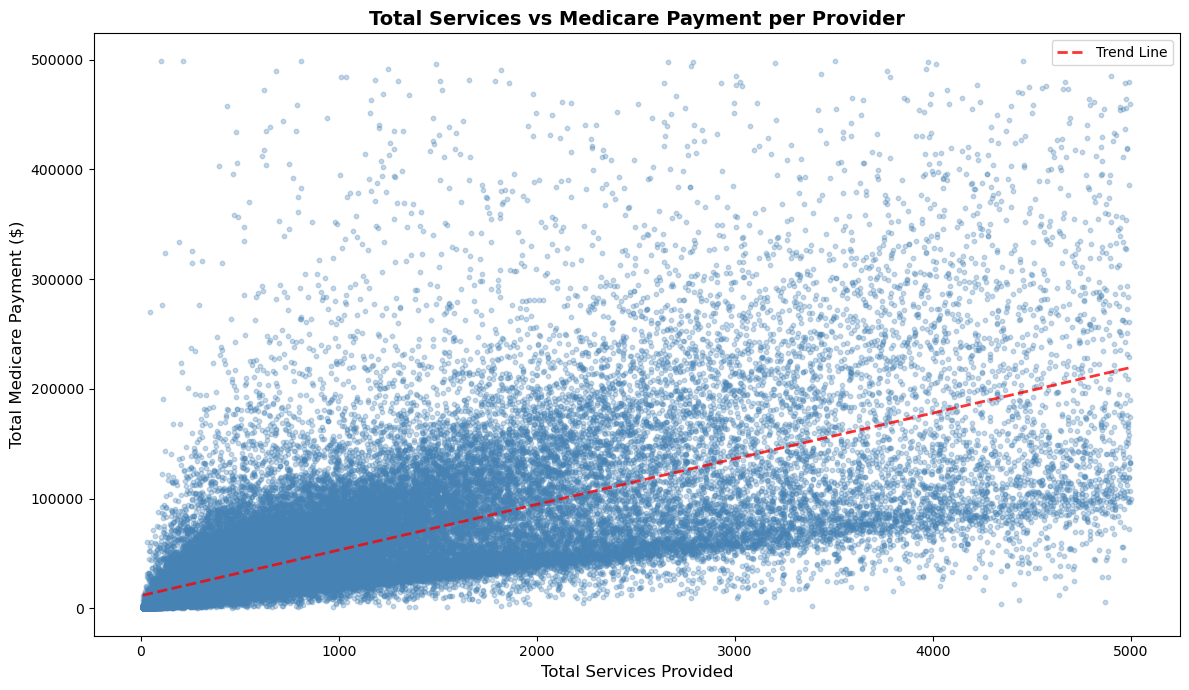

✅ Chart 4 saved!


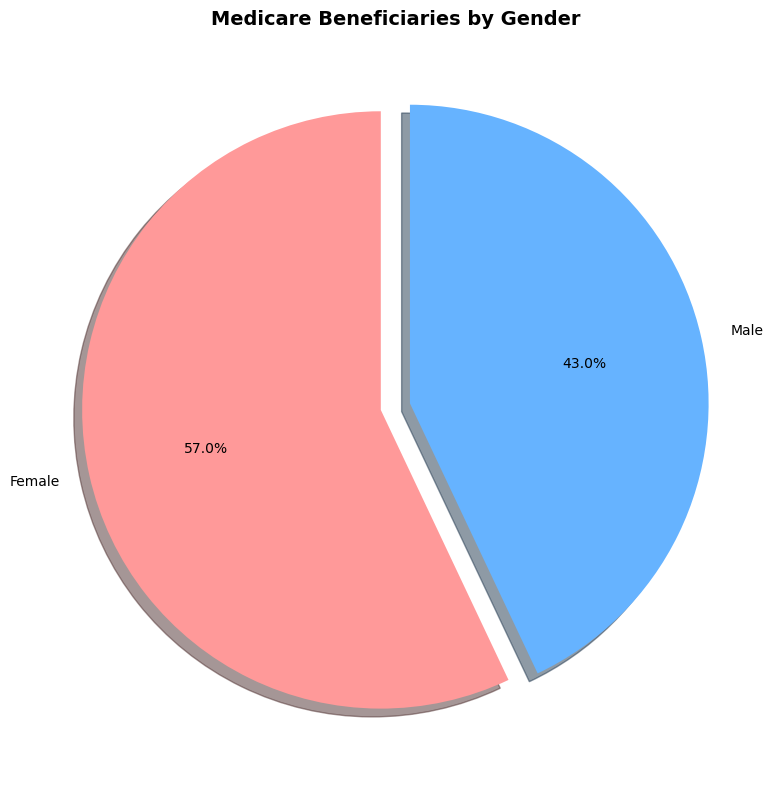

✅ Chart 5 saved!
   MEDICARE ANALYTICS PROJECT SUMMARY
📊 Dataset: CMS Medicare 2022
📝 Total Records Analyzed: 100,000
🏥 Unique Provider Types: 102
🗺️  States Covered: 58
💰 Total Medicare Payments: $8,982,084,097
👥 Total Beneficiaries: 30,759,188
⚕️  Avg Patient Risk Score: 1.54
✅ Charts Created: 5
✅ Clean Data Saved: medicare_clean.csv


In [6]:
# Chart 4: Services vs Medicare Payment Scatter Plot
plt.figure(figsize=(12, 7))
df_scatter = df_clean[
    (df_clean['Total_Services'] < 5000) & 
    (df_clean['Total_Medicare_Payment'] < 500000)
]
plt.scatter(df_scatter['Total_Services'], 
            df_scatter['Total_Medicare_Payment'],
            alpha=0.3, color='steelblue', s=10)
plt.title('Total Services vs Medicare Payment per Provider', fontsize=14, fontweight='bold')
plt.xlabel('Total Services Provided', fontsize=12)
plt.ylabel('Total Medicare Payment ($)', fontsize=12)
plt.ticklabel_format(style='plain', axis='y')
z = np.polyfit(df_scatter['Total_Services'], df_scatter['Total_Medicare_Payment'], 1)
p = np.poly1d(z)
plt.plot(sorted(df_scatter['Total_Services']), 
         p(sorted(df_scatter['Total_Services'])), 
         "r--", alpha=0.8, linewidth=2, label='Trend Line')
plt.legend()
plt.tight_layout()
plt.savefig('../output/services_vs_payment.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 4 saved!")

# Chart 5: Gender Distribution
plt.figure(figsize=(8, 8))
total_female = df_clean['Female_Count'].sum()
total_male = df_clean['Male_Count'].sum()
labels = ['Female', 'Male']
sizes = [total_female, total_male]
colors = ['#ff9999', '#66b3ff']
explode = (0.05, 0.05)
plt.pie(sizes, explode=explode, labels=labels, colors=colors,
        autopct='%1.1f%%', shadow=True, startangle=90)
plt.title('Medicare Beneficiaries by Gender', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../output/gender_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 5 saved!")

# Project Summary
print("=" * 50)
print("   MEDICARE ANALYTICS PROJECT SUMMARY")
print("=" * 50)
print(f"📊 Dataset: CMS Medicare 2022")
print(f"📝 Total Records Analyzed: {len(df_clean):,}")
print(f"🏥 Unique Provider Types: {df_clean['Provider_Type'].nunique()}")
print(f"🗺️  States Covered: {df_clean['State'].nunique()}")
print(f"💰 Total Medicare Payments: ${df_clean['Total_Medicare_Payment'].sum():,.0f}")
print(f"👥 Total Beneficiaries: {df_clean['Total_Beneficiaries'].sum():,}")
print(f"⚕️  Avg Patient Risk Score: {df_clean['Avg_Risk_Score'].mean():.2f}")
print(f"✅ Charts Created: 5")
print(f"✅ Clean Data Saved: medicare_clean.csv")
print("=" * 50)